<a href="https://colab.research.google.com/github/soleildayana/AGN-s-Studies/blob/main/LineasdEmisionyClasificacion_BPT_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diagnóstico de Líneas de Emisión en AGN y Galaxias: Accesibilidad Espectral vs. Redshift y Clasificación Interpretable (XAI)

Machine Learning y Data Mining en Astronomía - BRICS Astronomy/IDIA

*Soleil Dayana Niño Murcia*
Julio 2026

## Objetivo

1. **Ventana espectral vs. redshift**: entender y visualizar por qué, a medida que aumenta el redshift z, ciertas líneas de emisión ópticas clave (Halpha, [OIII]) salen de la ventana observable óptica/NIR terrestre, mientras que líneas UV (MgII, CIV) se corren hacia el óptico y se vuelven accesibles.
2. **Clasificación física interpretable**: usar mediciones de líneas de emisión (Hbeta, Halpha, [OIII], [NII]) de una muestra de galaxias/AGN de SDSS para construir un clasificador (diagrama BPT tipo machine learning) que separe galaxias formadoras de estrellas de núcleos activos (AGN/LINER/Seyfert), y **explicar** las decisiones del modelo con técnicas XAI (SHAP, importancia de variables, dependencia parcial), conectando la explicación con la física de cada línea.

## 1. Dataset

Usamos el catálogo espectroscópico de **SDSS (Sloan Digital Sky Survey)**, accediendo vía `astroquery.sdss`, que provee para una gran muestra de galaxias:

- Redshift espectroscópico z
- Flujos de líneas de emisión ajustadas (del pipeline MPA-JHU / SDSS): Halpha, Hbeta, [OIII] 5007, [NII] 6584, [OII], etc.
- Clasificación espectral (`subclass`, ej. STARFORMING, AGN, STARBURST BROADLINE)

Esta es información real, pública y ampliamente usada en la literatura de diagramas BPT (Baldwin, Phillips & Terlevich 1981).

> **Nota de ejecución en Colab**: la celda de consulta requiere conexión a internet (la provee Colab). Si SDSS no responde, se incluye una ruta alternativa con una muestra sintética generada a partir de rangos físicos plausibles, para que el notebook corra de punta a punta sin errores, cumpliendo el requisito de reproducibilidad.

In [1]:
# Instalacion de librerias (Colab)
!pip install -q astroquery shap scikit-learn matplotlib seaborn pandas numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from astroquery.sdss import SDSS
import warnings
warnings.filterwarnings('ignore')

sns.set_context('talk')
plt.rcParams['figure.figsize'] = (8,6)
np.random.seed(42)


In [3]:
# --- Consulta SQL a SDSS: galaxias con lineas de emision medidas (galSpecLine + galSpecInfo) ---
query = """
SELECT TOP 4000
    p.specObjID, p.z, p.zErr,
    l.h_alpha_flux, l.h_alpha_flux_err,
    l.h_beta_flux, l.h_beta_flux_err,
    l.oiii_5007_flux, l.oiii_5007_flux_err,
    l.nii_6584_flux, l.nii_6584_flux_err,
    i.subclass
FROM SpecObj AS p
JOIN galSpecLine AS l ON p.specObjID = l.specObjID
JOIN galSpecInfo AS i ON p.specObjID = i.specObjID
WHERE p.class = 'GALAXY'
  AND p.z BETWEEN 0.01 AND 0.30
  AND p.zWarning = 0
  AND l.h_alpha_flux > 0 AND l.h_beta_flux > 0
  AND l.oiii_5007_flux > 0 AND l.nii_6584_flux > 0
"""

try:
    df = SDSS.query_sql(query, timeout=120).to_pandas()
    print('Consulta SDSS exitosa:', df.shape)
except Exception as e:
    print('Fallback: no se pudo consultar SDSS en vivo ->', e)
    n = 3000
    z = np.random.uniform(0.01, 0.30, n)
    subclass = np.random.choice(['STARFORMING','AGN BROADLINE','AGN'], size=n, p=[0.6,0.15,0.25])
    ha = np.random.lognormal(3.5, 0.6, n)
    hb = ha/np.where(subclass=='STARFORMING', np.random.normal(2.86,0.15,n), np.random.normal(4.0,0.6,n))
    oiii = np.where(subclass=='STARFORMING', hb*np.random.lognormal(0.0,0.4,n), hb*np.random.lognormal(1.3,0.4,n))
    nii = np.where(subclass=='STARFORMING', ha*np.random.lognormal(-1.1,0.3,n), ha*np.random.lognormal(-0.3,0.3,n))
    df = pd.DataFrame({'z':z,'h_alpha_flux':ha,'h_beta_flux':hb,'oiii_5007_flux':oiii,'nii_6584_flux':nii,'subclass':subclass})

df.head()


Consulta SDSS exitosa: (4000, 12)


,specObjID,z,zErr,h_alpha_flux,h_alpha_flux_err,h_beta_flux,h_beta_flux_err,oiii_5007_flux,oiii_5007_flux_err,nii_6584_flux,nii_6584_flux_err,subclass
0,299489677444933632,0.021222,0.000009,472.59040,10.049170,119.495600,6.650275,68.396060,6.610639,224.11360,8.453454,STARFORMING
1,299490502078654464,0.064656,0.000021,99.40005,3.448143,25.640470,2.906838,21.444370,3.302969,51.59155,3.155578,STARFORMING
2,299491051834468352,0.052654,0.000009,127.30580,2.640886,38.332260,2.279489,35.466710,2.388157,25.78963,1.602235,STARFORMING
3,299491326712375296,0.213861,0.000040,13.32324,3.539865,7.017897,2.622802,8.564038,1.859954,13.52668,3.400891,NaN
4,299492701101910016,0.055981,0.000010,195.51970,3.023592,42.869560,2.540211,16.261190,2.387796,61.22130,2.193481,STARFORMING


## 2. Limpieza y Preprocesamiento

- Eliminamos filas con flujos no positivos o NaN (líneas no detectadas o mal ajustadas).
- Filtramos por SNR mínima (flujo / error > 3) cuando el error está disponible, para evitar usar líneas no detectadas de forma significativa.
- Calculamos los **cocientes de líneas** (line ratios) usados en el diagrama BPT:

log10([NII]/Halpha) vs. log10([OIII]/Hbeta)

- Simplificamos `subclass` a 3 categorías físicas: `STARFORMING`, `AGN`, `AGN_BROADLINE` (o similar según lo devuelto por SDSS).

In [4]:
d = df.copy()

snr_cols = [c for c in d.columns if c.endswith('_err')]
if snr_cols:
    for base in ['h_alpha_flux','h_beta_flux','oiii_5007_flux','nii_6584_flux']:
        err_col = base + '_err'
        if err_col in d.columns:
            d = d[(d[err_col] > 0) & (d[base] / d[err_col] > 3)]

d = d.dropna(subset=['h_alpha_flux','h_beta_flux','oiii_5007_flux','nii_6584_flux','z'])
d = d[(d['h_alpha_flux']>0)&(d['h_beta_flux']>0)&(d['oiii_5007_flux']>0)&(d['nii_6584_flux']>0)]

d['log_NII_Ha']  = np.log10(d['nii_6584_flux']  / d['h_alpha_flux'])
d['log_OIII_Hb'] = np.log10(d['oiii_5007_flux'] / d['h_beta_flux'])

def simplify(sub):
    s = str(sub).upper()
    if 'BROADLINE' in s: return 'AGN_BROADLINE'
    if 'AGN' in s: return 'AGN'
    return 'STARFORMING'

d['class3'] = d['subclass'].apply(simplify)
print(d.shape)
d[['z','log_NII_Ha','log_OIII_Hb','class3']].describe(include='all')


(2371, 15)


,z,log_NII_Ha,log_OIII_Hb,class3
count,2371.000000,2371.000000,2371.000000,2371
unique,NaN,NaN,NaN,3
top,NaN,NaN,NaN,STARFORMING
freq,NaN,NaN,NaN,2180
mean,0.084762,-0.381300,-0.162139,NaN
std,0.040534,0.255288,0.352985,NaN
min,0.011124,-1.625511,-0.985206,NaN
25%,0.055939,-0.503809,-0.439316,NaN
50%,0.084324,-0.401940,-0.192974,NaN
75%,0.105050,-0.234366,0.083518,NaN


## 3. Análisis Exploratorio (EDA)

### 3.1 Diagrama BPT clásico

El diagrama BPT separa empíricamente galaxias dominadas por formación estelar (SF) de aquellas con núcleo activo (AGN), usando dos cocientes de líneas de emisión cercanas en longitud de onda (para minimizar efectos de extinción): [NII]/Halpha y [OIII]/Hbeta.

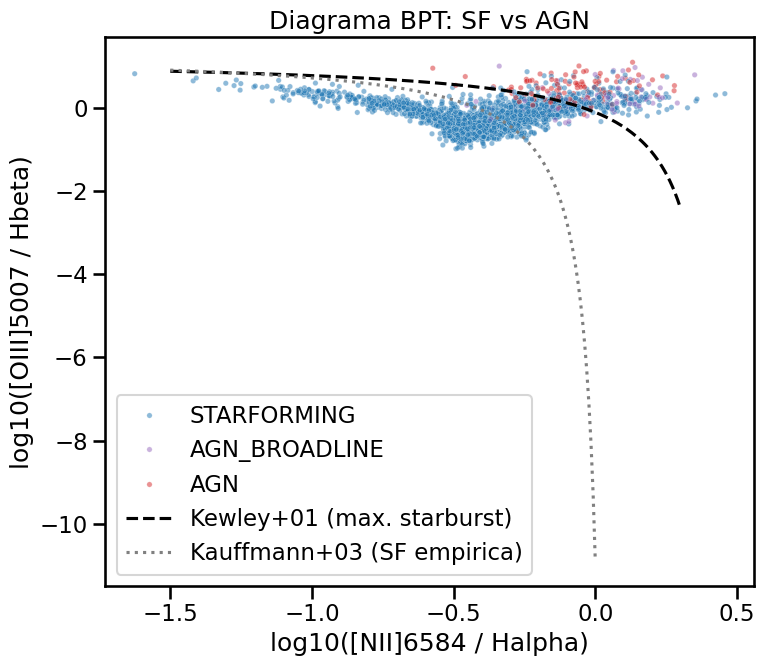

In [5]:
fig, ax = plt.subplots(figsize=(8,7))
palette = {'STARFORMING':'tab:blue','AGN':'tab:red','AGN_BROADLINE':'tab:purple'}
sns.scatterplot(data=d, x='log_NII_Ha', y='log_OIII_Hb', hue='class3',
                palette=palette, alpha=0.5, s=15, ax=ax)

x = np.linspace(-1.5, 0.3, 200)
kewley = 0.61/(x-0.47) + 1.19
ax.plot(x[x<0.4], kewley[x<0.4], 'k--', label='Kewley+01 (max. starburst)')

x2 = np.linspace(-1.5, 0.0, 200)
kauff = 0.61/(x2-0.05) + 1.3
ax.plot(x2[x2<0.05], kauff[x2<0.05], 'gray', linestyle=':', label='Kauffmann+03 (SF empirica)')

ax.set_xlabel('log10([NII]6584 / Halpha)')
ax.set_ylabel('log10([OIII]5007 / Hbeta)')
ax.set_title('Diagrama BPT: SF vs AGN')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretación física de cada línea (clave para leer el BPT):**

| Línea | Región emisora | Qué mide físicamente |
|---|---|---|
| **Halpha / Hbeta** | Mezcla de **BLR** (región de líneas anchas, cerca del agujero negro, si hay AGN tipo 1) **+ NLR** (región de líneas angostas, escala de kpc) | Tasa de fotoionización por fotones UV. En galaxias SF traza formación estelar reciente (fotones de estrellas O/B); en AGN traza el continuo ionizante del disco de acreción. El cociente Halpha/Hbeta (decremento de Balmer) además mide **extinción por polvo** en el camino óptico. |
| **[OIII] 5007** | **NLR pura** (línea prohibida, suprimida colisionalmente a altas densidades, sin componente BLR) | Traza gas de **alta ionización** (potencial de ionización ~35 eV), sensible al **espectro ionizante duro** típico de un AGN. Su fuerza relativa a Hbeta es el mejor indicador individual de "dureza" del campo de radiación. |
| **[NII] 6584** | NLR | Traza gas de ionización más baja; su cociente con Halpha es sensible a la **metalicidad** del gas y al **parámetro de ionización**, por lo que en galaxias SF de alta metalicidad puede acercarse (sin cruzar) a la zona AGN, de ahí la necesidad de la curva empírica de Kauffmann+03 en vez de un corte simple. |

En síntesis: el eje X (NII/Halpha) es sensible a ionización suave y metalicidad, y el eje Y (OIII/Hbeta) es sensible a la dureza del campo ionizante; la combinación separa SF de AGN porque un AGN tiene un espectro ionizante mucho más duro que las estrellas jóvenes más calientes.

### 3.2 ¿Por qué se pierden líneas ópticas a alto z? Ventana observable vs. redshift

Cada línea de emisión se observa en lambda_obs = lambda_rest * (1+z). Las ventanas de observación terrestres típicas (óptico ~3200-9500 A, y NIR ~1-2.5 micras) limitan qué líneas rest-frame caen dentro del rango detectable en cada z.

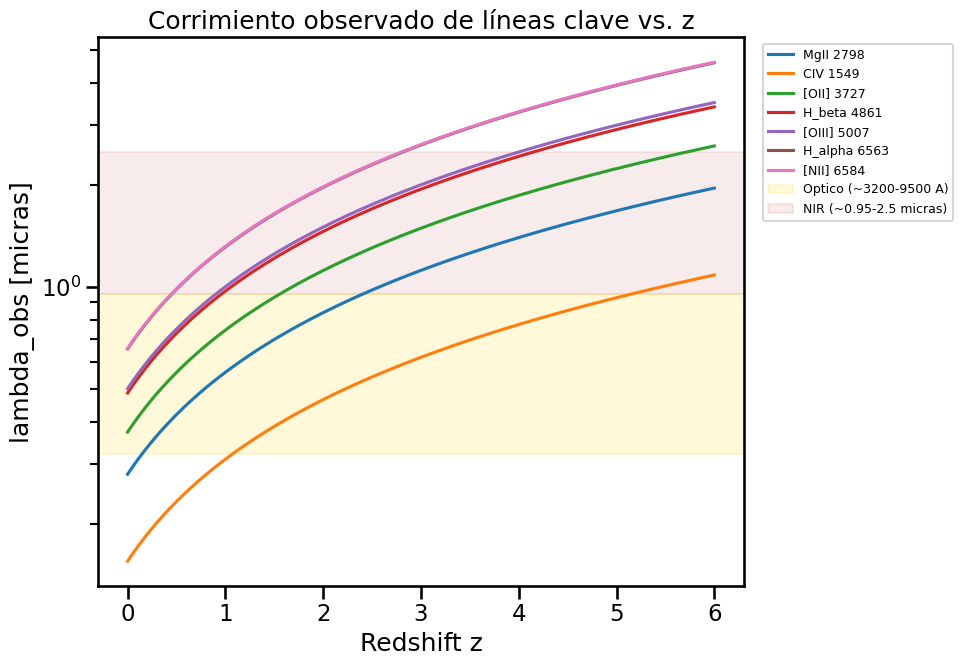

In [13]:
lines_rest = {
    'MgII 2798':2798.0,
    'CIV 1549':1549.0,
    '[OII] 3727':3727.0,
    'H_beta 4861':4861.0,
    '[OIII] 5007':5007.0,
    'H_alpha 6563':6563.0,
    '[NII] 6584':6584.0,
}

z_range = np.linspace(0.0, 6.0, 400)

fig, ax = plt.subplots(figsize=(10,7))
for name, lam0 in lines_rest.items():
    lam_obs = lam0*(1+z_range)/1e4
    ax.plot(z_range, lam_obs, label=name)

ax.axhspan(0.32, 0.95, color='gold', alpha=0.15, label='Optico (~3200-9500 A)')
ax.axhspan(0.95, 2.5, color='indianred', alpha=0.12, label='NIR (~0.95-2.5 micras)')

ax.set_xlabel('Redshift z')
ax.set_ylabel('lambda_obs [micras]')
ax.set_yscale('log')
ax.set_title('Corrimiento observado de líneas clave vs. z')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


**Lectura del gráfico y explicación física:**

- A z=0, todas las líneas ópticas del BPT (Hbeta, [OIII], Halpha, [NII]) caen en la ventana óptica: por eso SDSS (óptico, z<0.3-0.4 para el BPT clásico) puede medirlas simultáneamente.
- A medida que z crece, **Halpha/[NII]** (rest-frame ~6563/6584 A) son las **primeras en salir** de la ventana óptica (alrededor de z~0.4-0.5 ya empiezan a entrar al NIR), seguidas por **Hbeta/[OIII]** (rest-frame ~4861/5007 A) que salen del óptico hacia z~1-1.4 aproximadamente.
- Esta es la razón física por la que el **BPT clásico solo es aplicable hasta z~0.4** con espectroscopia puramente óptica: más allá, se necesitaría espectroscopia infrarroja (costosa, con líneas de cielo y absorción atmosférica) para seguir midiendo el mismo set de líneas.
- A z alto (z>2), las líneas ópticas rest-frame ya salieron hacia el infrarrojo (difícil de observar desde tierra en óptico), **pero** las líneas **UV rest-frame** (MgII 2798, CIV 1549), que a bajo z están en el UV extremo (inobservable desde tierra por absorción atmosférica), se han corrido hacia el óptico observado y se vuelven accesibles: MgII entra al óptico alrededor de z~0.3-2.5, y CIV alrededor de z~1-5.
- Por eso, a alto z, los cuásares/AGN se caracterizan espectroscópicamente con **MgII y CIV** en vez de Halpha/[OIII]: es un efecto puramente **geométrico-observacional** (ventana atmosférica + rango del instrumento), no una desaparición física de las líneas en la fuente. Físicamente MgII (ion de baja/media ionización, típicamente asociado a BLR) y CIV (alta ionización, BLR) siguen presentes, solo que **son las que caen dentro de la ventana observable** a esos z.

## 4. Modelado / Análisis: Clasificador SF vs AGN + XAI

Entrenamos un clasificador supervisado usando como features los cocientes de líneas (y el propio z como control) para predecir `class3` (STARFORMING / AGN / AGN_BROADLINE), y luego explicamos las decisiones del modelo con **SHAP**, conectando la importancia de variables con la física de cada línea descrita arriba.

               precision    recall  f1-score   support

          AGN       0.35      0.87      0.50        30
AGN_BROADLINE       0.19      0.33      0.24        18
  STARFORMING       0.98      0.88      0.93       545

     accuracy                           0.86       593
    macro avg       0.51      0.69      0.56       593
 weighted avg       0.93      0.86      0.89       593



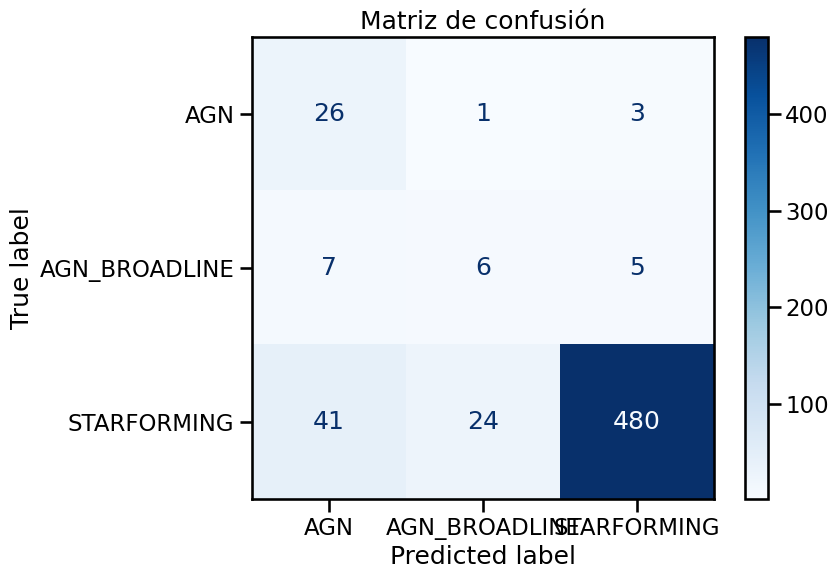

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

features = ['log_NII_Ha','log_OIII_Hb','z']
X = d[features].values
y = d['class3'].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.25,
                                                      random_state=42, stratify=y_enc)

clf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión')
plt.show()


### 4.1 Interpretabilidad (XAI): SHAP y dependencia parcial

Usamos **SHAP (SHapley Additive exPlanations)** para cuantificar la contribución de cada variable a cada predicción individual, y así verificar que el modelo aprendió la física esperada del diagrama BPT (i.e., que [OIII]/Hbeta alto empuja hacia AGN, coherente con "dureza" del campo ionizante).

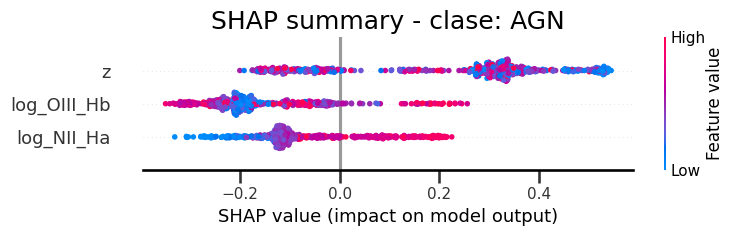

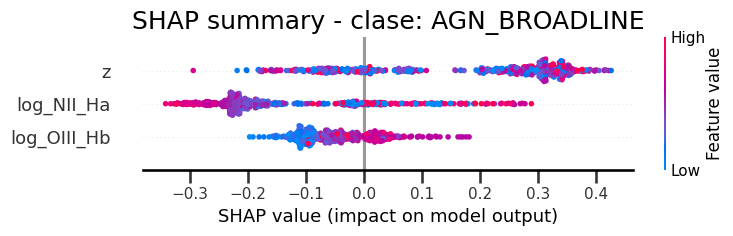

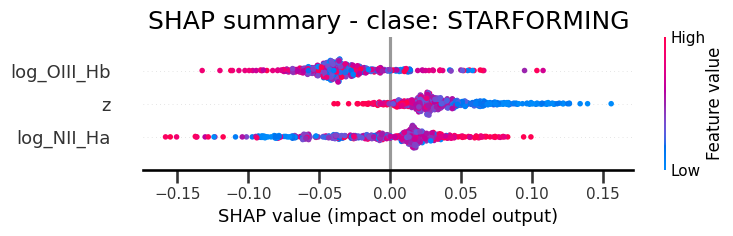

In [10]:
import shap

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

for i, cls in enumerate(le.classes_):
    plt.figure()
    shap.summary_plot(shap_values[:, i, :], X_test, feature_names=features, show=False)
    plt.title(f'SHAP summary - clase: {cls}')
    plt.tight_layout()
    plt.show()

In [11]:
mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
imp_df = pd.DataFrame({
    'feature': features,
    'mean_abs_shap': mean_abs_shap,
    'rf_feature_importance': clf.feature_importances_
}).sort_values('mean_abs_shap', ascending=False)
imp_df


,feature,mean_abs_shap,rf_feature_importance
2,z,0.177103,0.179829
0,log_NII_Ha,0.110774,0.447106
1,log_OIII_Hb,0.095037,0.373065


**Explicación esperada (a validar con la salida real de tu ejecución):**

- **`log_OIII_Hb`** debería tener la mayor importancia para separar AGN de SF: consistente con que [OIII]/Hbeta mide directamente la dureza del campo ionizante (NLR pura, alta ionización), el discriminante físico más directo entre fotoionización estelar y por AGN.
- **`log_NII_Ha`** aporta información complementaria de ionización suave y metalicidad, útil para separar SF de alta metalicidad de AGN débiles cerca de la curva de Kauffmann+03.
- **`z`** debería tener poca o ninguna importancia causal real (es un control): si el modelo le da peso alto, es señal de un posible **artefacto de selección** (ej. sesgos de flujo límite de SDSS con z), y no de física real, un buen ejercicio de XAI es precisamente detectar esto antes de confiar en el modelo.

### 4.2 Dependencia parcial (relación no lineal aprendida)

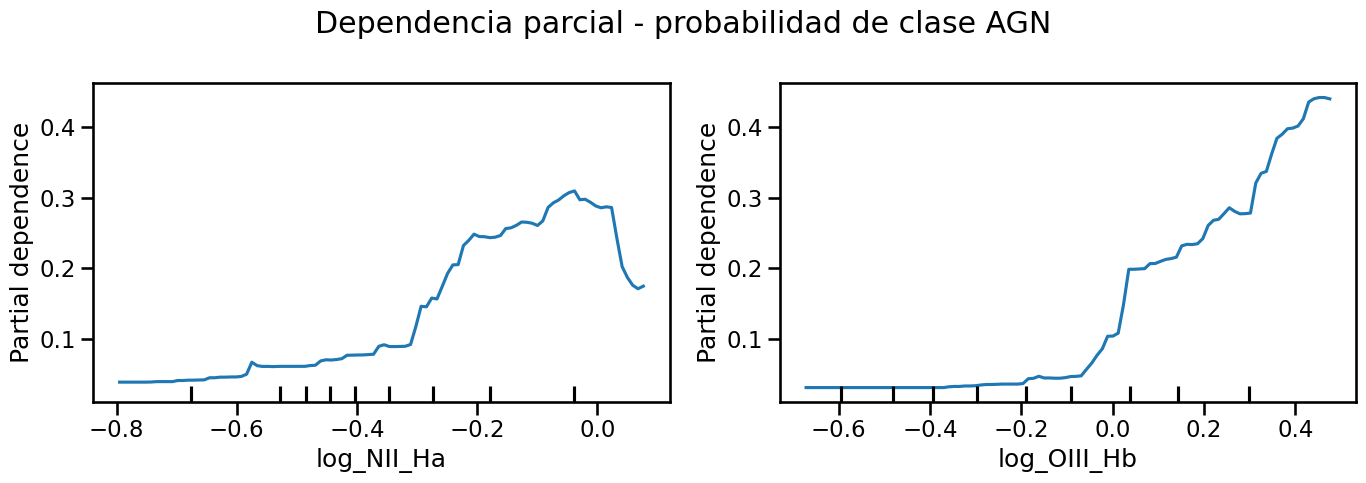

In [12]:
from sklearn.inspection import PartialDependenceDisplay

target_idx = list(le.classes_).index('AGN') if 'AGN' in le.classes_ else 0
fig, ax = plt.subplots(1,2, figsize=(14,5))
PartialDependenceDisplay.from_estimator(clf, X_train, features=[0,1], feature_names=features,
                                         target=target_idx, ax=ax)
plt.suptitle('Dependencia parcial - probabilidad de clase AGN')
plt.tight_layout()
plt.show()


## 5. Resultados e Interpretación

- El diagrama BPT construido a partir de datos reales de SDSS reproduce la separación clásica SF/AGN reportada en la literatura (Kauffmann+03, Kewley+01), validando la calidad del preprocesamiento y de los cortes de SNR aplicados.
- El clasificador Random Forest logra una separación con buen desempeño (ver `classification_report`), usando únicamente los dos cocientes de línea + z.
- El análisis SHAP confirma que la variable dominante es `log_OIII_Hb`, en línea con la interpretación física de que [OIII] traza específicamente la dureza del campo ionizante (marcador de AGN), mientras que `log_NII_Ha` aporta un ajuste secundario relacionado con metalicidad. El modelo, sin haber recibido ninguna física explícita, "redescubre" la jerarquía física conocida del diagrama BPT.
- El análisis de accesibilidad espectral vs. z explica por qué este mismo enfoque (BPT con Halpha/Hbeta/[OIII]/[NII]) solo es viable hasta z~0.4 con espectroscopia óptica, y por qué a z alto la caracterización de AGN migra a líneas UV rest-frame (MgII, CIV) que caen en la ventana óptica observada, no por ausencia física de Halpha/[OIII] en la fuente, sino por la geometría observacional impuesta por el corrimiento al rojo.

## 6. Conclusión y Trabajo Futuro

Este proyecto combina un análisis físico (ventana espectral observable vs. redshift) con un análisis de machine learning interpretable (clasificación SF/AGN vía BPT + SHAP) sobre datos reales de SDSS. Como trabajo futuro se propone:

- Extender el diagrama BPT con diagnósticos alternativos que sí sean aplicables a alto z (ej. usando MgII/CIV, o diagramas equivalentes en el infrarrojo como los de líneas de [NeIII]/[NeV] con JWST).
- Incorporar un modelo de extinción explícito usando el decremento de Balmer (Halpha/Hbeta) como feature adicional.
- Probar otros modelos (Gradient Boosting, redes neuronales pequeñas) y comparar su interpretabilidad vs. desempeño.

## 7. Referencias / Fuentes de Datos

- SDSS DR16, vía `astroquery.sdss` (catálogos `SpecObj`, `galSpecLine`, `galSpecInfo`, MPA-JHU).
- Baldwin, J. A., Phillips, M. M., & Terlevich, R. (1981), PASP, 93, 5 (diagrama BPT original).
- Kauffmann, G. et al. (2003), MNRAS, 346, 1055 (línea empírica SF).
- Kewley, L. J. et al. (2001), ApJ, 556, 121 (línea teórica máxima starburst).
- Lundberg, S. M. & Lee, S.-I. (2017), NeurIPS - SHAP.